In [1]:
import pandas as pd

df = pd.read_json("../results/final-gemini.jsonl", lines=True)
df

,patient_data,image_path,lab_report,triage_result,diagnose_result,critique_report,final_report,retrieved_cases,trace,ground_truth
0,"{'age': '60', 'sex': 'female', 'lesion_locatio...",../dataset/test/ISIC_0031591.jpg,"{'patient_data': {'age': '60', 'sex': 'female'...","{'disease_family': 'Keratinocytic', 'confidenc...","{'diagnosis': 'Pigmented benign keratosis', 'c...",{'critique_assessment': {'confidence_justified...,"{'final_diagnosis': 'Basal cell carcinoma', 'c...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Pigmented benign keratosis
1,"{'age': '55', 'sex': 'male', 'lesion_location'...",../dataset/test/ISIC_0029541.jpg,"{'patient_data': {'age': '55', 'sex': 'male', ...","{'disease_family': 'Keratinocytic', 'confidenc...","{'diagnosis': 'Actinic Keratosis', 'confidence...",{'critique_assessment': {'confidence_justified...,"{'final_diagnosis': 'Squamous cell carcinoma',...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Squamous cell carcinoma
2,"{'age': '80', 'sex': 'female', 'lesion_locatio...",../dataset/test/ISIC_0032173.jpg,"{'patient_data': {'age': '80', 'sex': 'female'...","{'disease_family': 'Keratinocytic', 'confidenc...","{'diagnosis': 'Pigmented benign keratosis', 'c...",{'critique_assessment': {'confidence_justified...,"{'final_diagnosis': 'Squamous cell carcinoma',...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Squamous cell carcinoma
3,"{'age': '70', 'sex': 'male', 'lesion_location'...",../dataset/test/ISIC_0029043.jpg,"{'patient_data': {'age': '70', 'sex': 'male', ...","{'disease_family': 'Keratinocytic', 'confidenc...","{'diagnosis': 'Actinic Keratosis', 'confidence...",{'critique_assessment': {'confidence_justified...,"{'final_diagnosis': 'Squamous cell carcinoma',...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Squamous cell carcinoma
4,"{'age': '45', 'sex': 'female', 'lesion_locatio...",../dataset/test/ISIC_0026537.jpg,"{'patient_data': {'age': '45', 'sex': 'female'...","{'disease_family': 'Melanocytic', 'confidence'...","{'diagnosis': 'Nevus', 'confidence': 'Medium',...",{'critique_assessment': {'confidence_justified...,"{'final_diagnosis': 'Nevus', 'confidence': 'Me...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Nevus
...,...,...,...,...,...,...,...,...,...,...
295,"{'age': '80.0', 'sex': 'male', 'lesion_locatio...",../dataset/test/ISIC_0029041.jpg,"{'patient_data': {'age': '80.0', 'sex': 'male'...","{'disease_family': 'Keratinocytic', 'confidenc...","{'diagnosis': 'Squamous cell carcinoma', 'conf...","{'_raw': '```json { ""critique_assessment"": {...","{'final_diagnosis': 'Squamous cell carcinoma',...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Actinic Keratosis
296,"{'age': '5.0', 'sex': 'female', 'lesion_locati...",../dataset/test/ISIC_0033352.jpg,"{'patient_data': {'age': '5.0', 'sex': 'female...","{'disease_family': 'Melanocytic', 'confidence'...","{'diagnosis': 'Nevus', 'confidence': 'High', '...",{'critique_assessment': {'confidence_justified...,"{'final_diagnosis': 'Melanoma', 'confidence': ...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Nevus
297,"{'age': '70.0', 'sex': 'female', 'lesion_locat...",../dataset/test/ISIC_0027435.jpg,"{'patient_data': {'age': '70.0', 'sex': 'femal...","{'disease_family': 'Keratinocytic', 'confidenc...","{'diagnosis': 'Pigmented benign keratosis', 'c...",{'critique_assessment': {'confidence_justified...,"{'final_diagnosis': 'Actinic keratosis', 'conf...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Pigmented benign keratosis
298,"{'age': '80.0', 'sex': 'female', 'lesion_locat...",../dataset/test/ISIC_0033307.j

In [2]:
df.loc[0, "trace"]

[{'agent': 'lab_technician',
  'role': 'user',
  'payload': {'patient_data': {'age': '60',
    'sex': 'female',
    'lesion_location': 'head, neck',
    'is_melanocytic': False},
   'visual_summary': {'symmetry': 'Asymmetrical',
    'colors': ['light brown', 'dark brown', 'white', 'pink', 'red'],
    'border_characteristics': 'Ill-defined and Irregular'},
   'dermoscopic_features': [{'feature_name': 'Pseudonetwork/Rhombohedral structures',
     'description': 'A prominent light to dark brown pseudonetwork is visible, particularly in the central and upper-left portions of the lesion. This pattern is characterized by brown dots and globules forming a reticular arrangement with intervening white to light pink areas, consistent with a pseudonetwork on facial skin due to the presence of follicular openings.'},
    {'feature_name': 'Brown Dots and Globules',
     'description': 'Numerous small, dark brown dots and globules are scattered throughout the lesion, often concentrated within the ps

In [ ]:
from pathlib import Path
import json, re

def clean_raw_json(raw_str):
    cleaned = ''.join(
        c if ord(c) >= 32 and c != '\x7f' else ' '
        for c in raw_str
    )
    
    cleaned = re.sub(r'(?<!\\)(?:\\\\)*\n', '\\\\n', cleaned)
    cleaned = re.sub(r'(?<!\\)(?:\\\\)*\r', '\\\\r', cleaned)

    # Make sure we didn’t lose the opening {
    stripped = cleaned.strip()
    if not stripped.startswith('{'):
        # Try to find the first '{' and cut everything before it
        pos = cleaned.find('{')
        if pos != -1:
            cleaned = cleaned[pos:]
        else:
            # prepend {
            cleaned = '{' + cleaned

    # Make sure it ends with }
    if not cleaned.strip().endswith('}'):
        pos = cleaned.rfind('}')
        if pos != -1:
            cleaned = cleaned[:pos+1]
        else:
            # fallback safety
            cleaned = cleaned + '}'

    return cleaned


csv_payload = []
for index, item in df.iterrows():
    trace = item["trace"]
    _retrieved_cases = item["retrieved_cases"]
    retrieved_cases = []
    ground_truth = item["ground_truth"]
    image_path = Path(item["image_path"]).stem
    
    for rc in _retrieved_cases:
        retrieved_cases.append({
            "image_path": Path(rc["image_path"]).stem,
            "age": rc["age"],
            "sex": rc["sex"],
            "diagnosis": rc["diagnosis"],
            "lesion_location": rc["anatom_site"],
            "melanocytic": rc["melanocytic"],
            "sim_score": rc["score"]
        })
    
    dx_agent_payload = next((t for t in trace if t.get("agent") == "synthesizer"), None)
    if not dx_agent_payload:
        csv_payload.append({
            "image_path": image_path,
            "diagnosis": None,
            "reasoning": None,
            "confidence": None,
            "differential": None,
            "ground_truth": ground_truth,
            "retrieved_cases": None,
            "summary": None
        })
        continue

    payload = dx_agent_payload.get("payload", None)
    if not payload:
        # Handle missing payload
        data = {}
    elif isinstance(payload, dict) and '_raw' not in payload:
        # Normal case: already parsed
        data = payload
    elif isinstance(payload, dict) and '_raw' in payload:
        raw_json_str = payload['_raw']
        
        # Clean the problematic string concatenations
        cleaned_str = clean_raw_json(raw_json_str)

        try:
            data = json.loads(cleaned_str)
        except (json.JSONDecodeError, TypeError) as e:
            print(f"Failed to parse cleaned _raw JSON at index {index}: {e}")
            print(f"Raw (cleaned): {cleaned_str[700:750]}...")  # Print context near error
            data = {}
    else:
        data = {}
        
    diagnosis = data.get("final_diagnosis")
    confidence = data.get("confidence")
    differential = data.get("differential_diagnosis")  

    reasoning = data.get("reasoning", {})

    # Append to list
    csv_payload.append({
        "image_path": image_path,
        "diagnosis": diagnosis,
        "ground_truth": ground_truth,
        "confidence": confidence,
        "differential": differential,
        "retrieved_cases": retrieved_cases,
        "reasoning": reasoning
    })


df_payload = pd.DataFrame(csv_payload)

In [16]:
df_payload.isna().sum()

image_path         0
diagnosis          0
ground_truth       0
confidence         0
differential       0
retrieved_cases    0
reasoning          0
dtype: int64

In [17]:
df_payload[df_payload.isna().any(axis=1)]

,image_path,diagnosis,ground_truth,confidence,differential,retrieved_cases,reasoning


In [18]:
# df.loc[295, "trace"][-1]

In [19]:
df_payload.dropna(subset=['diagnosis'], inplace=True)
df_payload.isna().sum()

image_path         0
diagnosis          0
ground_truth       0
confidence         0
differential       0
retrieved_cases    0
reasoning          0
dtype: int64

In [20]:
df_payload["diagnosis"].value_counts()

diagnosis
Melanoma                      88
Nevus                         86
Basal cell carcinoma          40
Squamous cell carcinoma       37
Pigmented benign keratosis    27
Actinic Keratosis             12
Dermatofibroma                 9
Name: count, dtype: int64

In [21]:
df_payload["ground_truth"].value_counts()

ground_truth
Nevus                         135
Pigmented benign keratosis     40
Melanoma                       40
Basal cell carcinoma           30
Squamous cell carcinoma        23
Dermatofibroma                 16
Actinic Keratosis              15
Name: count, dtype: int64

In [22]:
label_mapping = {
    "nevus": "Nevus",
    "Atypical Nevus": "Nevus",
    "Melanocytic nevus": "Nevus",
    "melanoma": "Melanoma",
    "pigment benign keratosis (pbk)": "Pigmented benign keratosis",
    "pbk": "Pigmented benign keratosis",
    "Pigmented Benign Keratosis": "Pigmented benign keratosis",
    "actinic keratosis (ak)": "Actinic Keratosis",
    "Actinic Keratosis": "Actinic Keratosis",
    "Actinic keratosis": "Actinic Keratosis",
    "ak": "Actinic Keratosis",
    "basal cell carcinoma": "Basal cell carcinoma",
    "Basal Cell Carcinoma": "Basal cell carcinoma",
    "scc": "Squamous cell carcinoma",
    "Squamous Cell Carcinoma": "Squamous cell carcinoma",
    "df": "Dermatofibroma",
    "dermatofibroma": "Dermatofibroma"
}

def normalize_label(label):
    if isinstance(label, str):
        return label_mapping.get(label.strip(), label.strip())
    return label 

In [23]:
df_payload['diagnosis'] = df_payload['diagnosis'].apply(normalize_label)
df_payload['ground_truth'] = df_payload['ground_truth'].apply(normalize_label)

In [24]:
df_payload["diagnosis"].value_counts()

diagnosis
Melanoma                      88
Nevus                         86
Basal cell carcinoma          40
Squamous cell carcinoma       37
Pigmented benign keratosis    27
Actinic Keratosis             12
Dermatofibroma                 9
Name: count, dtype: int64

In [25]:
df_payload = df_payload[df_payload["diagnosis"] != "Undetermined"]

In [26]:
df_payload["confidence"].value_counts()

confidence
High      146
Medium    138
Low        15
Name: count, dtype: int64

In [27]:
df_payload[(df_payload["ground_truth"] == "Nevus") & (df_payload["diagnosis"] != "Nevus")]
# df_payload[df_payload["ground_truth"] == "Dermatofibroma"]

,image_path,diagnosis,ground_truth,confidence,differential,retrieved_cases,reasoning
9,ISIC_0024944,Melanoma,Nevus,High,Nevus,"[{'image_path': 'ISIC_0024558', 'age': 70, 'se...",The lesion presents as a centrally dark brown ...
15,ISIC_0029484,Melanoma,Nevus,High,Nevus,"[{'image_path': 'ISIC_0026946', 'age': 45, 'se...",The lesion exhibits a highly disorganized gest...
17,ISIC_0032706,Melanoma,Nevus,High,Nevus,"[{'image_path': 'ISIC_0036049', 'age': 40, 'se...",The lesion's gestalt is characterized by marke...
24,ISIC_0031079,Melanoma,Nevus,High,Nevus,"[{'image_path': 'ISIC_0028524', 'age': 25, 'se...","The lesion presents with a centrally dense, da..."
27,ISIC_0024560,Melanoma,Nevus,High,Nevus,"[{'image_path': 'ISIC_0035009', 'age': 35, 'se...","The lesion presents as a large, highly asymmet..."
33,ISIC_0029753,Melanoma,Nevus,High,Nevus,"[{'image_path': 'ISIC_0025139', 'age': 35, 'se...",The lesion's gestalt is characterized by marke...
35,ISIC_0028092,Melanoma,Nevus,High,Nevus,"[{'image_path': 'ISIC_0030061', 'age': 45, 'se...","The lesion's gestalt is a large, highly asymme..."
38,ISIC_0030921,Melanoma,Nevus,Medium,Nevus,"[{'image_path': 'ISIC_0029477', 'age': 85, 'se...",The lesion presents a multi-component pattern ...
50,ISIC_0027251,Melanoma,Nevus,Medium,Nevus,"[{'image_path': 'ISIC_0026677', 'age': 55, 'se...",The lesion's gestalt is characterized by an as...
51,ISIC_0034350,Melanoma,Nevus,Medium,Nevus,"[{'image_path': 'ISIC_0030199', 'age': 40, 'se...",The lesion's gestalt is characterized by an ir...


In [28]:
tmp = df_payload[(df_payload["ground_truth"] == "Pigmented benign keratosis") & (df_payload["diagnosis"] != "Pigmented benign keratosis")]
print(tmp["image_path"].tolist())

['ISIC_0031591', 'ISIC_0031196', 'ISIC_0025275', 'ISIC_0025928', 'ISIC_0029068', 'ISIC_0034720', 'ISIC_0034684', 'ISIC_0032445', 'ISIC_0029260', 'ISIC_0031639', 'ISIC_0035631', 'ISIC_0028623', 'ISIC_0028123', 'ISIC_0033829', 'ISIC_0033041', 'ISIC_0025885', 'ISIC_0027435', 'ISIC_0033307']


In [29]:
## Initial Diagnosis
df_no_c = pd.read_json("../results/final-gemini.jsonl", lines=True)
df_no_c.head(5)

,patient_data,image_path,lab_report,triage_result,diagnose_result,critique_report,final_report,retrieved_cases,trace,ground_truth
0,"{'age': '60', 'sex': 'female', 'lesion_locatio...",../dataset/test/ISIC_0031591.jpg,"{'patient_data': {'age': '60', 'sex': 'female'...","{'disease_family': 'Keratinocytic', 'confidenc...","{'diagnosis': 'Pigmented benign keratosis', 'c...",{'critique_assessment': {'confidence_justified...,"{'final_diagnosis': 'Basal cell carcinoma', 'c...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Pigmented benign keratosis
1,"{'age': '55', 'sex': 'male', 'lesion_location'...",../dataset/test/ISIC_0029541.jpg,"{'patient_data': {'age': '55', 'sex': 'male', ...","{'disease_family': 'Keratinocytic', 'confidenc...","{'diagnosis': 'Actinic Keratosis', 'confidence...",{'critique_assessment': {'confidence_justified...,"{'final_diagnosis': 'Squamous cell carcinoma',...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Squamous cell carcinoma
2,"{'age': '80', 'sex': 'female', 'lesion_locatio...",../dataset/test/ISIC_0032173.jpg,"{'patient_data': {'age': '80', 'sex': 'female'...","{'disease_family': 'Keratinocytic', 'confidenc...","{'diagnosis': 'Pigmented benign keratosis', 'c...",{'critique_assessment': {'confidence_justified...,"{'final_diagnosis': 'Squamous cell carcinoma',...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Squamous cell carcinoma
3,"{'age': '70', 'sex': 'male', 'lesion_location'...",../dataset/test/ISIC_0029043.jpg,"{'patient_data': {'age': '70', 'sex': 'male', ...","{'disease_family': 'Keratinocytic', 'confidenc...","{'diagnosis': 'Actinic Keratosis', 'confidence...",{'critique_assessment': {'confidence_justified...,"{'final_diagnosis': 'Squamous cell carcinoma',...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Squamous cell carcinoma
4,"{'age': '45', 'sex': 'female', 'lesion_locatio...",../dataset/test/ISIC_0026537.jpg,"{'patient_data': {'age': '45', 'sex': 'female'...","{'disease_family': 'Melanocytic', 'confidence'...","{'diagnosis': 'Nevus', 'confidence': 'Medium',...",{'critique_assessment': {'confidence_justified...,"{'final_diagnosis': 'Nevus', 'confidence': 'Me...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Nevus


In [ ]:
from pathlib import Path
import json, re

def clean_raw_json(raw_str):
    cleaned = ''.join(
        c if ord(c) >= 32 and c != '\x7f' else ' '
        for c in raw_str
    )
    
    cleaned = re.sub(r'(?<!\\)(?:\\\\)*\n', '\\\\n', cleaned)
    cleaned = re.sub(r'(?<!\\)(?:\\\\)*\r', '\\\\r', cleaned)

    # Make sure we didn’t lose the opening {
    stripped = cleaned.strip()
    if not stripped.startswith('{'):
        # Try to find the first '{' and cut everything before it
        pos = cleaned.find('{')
        if pos != -1:
            cleaned = cleaned[pos:]
        else:
            # Desperate: prepend {
            cleaned = '{' + cleaned

    # Make sure it ends with }
    if not cleaned.strip().endswith('}'):
        pos = cleaned.rfind('}')
        if pos != -1:
            cleaned = cleaned[:pos+1]
        else:
            # Fallback safety
            cleaned = cleaned + '}'

    return cleaned


csv_payload = []
for index, item in df_no_c.iterrows():
    trace = item["trace"]
    _retrieved_cases = item["retrieved_cases"]
    retrieved_cases = []
    ground_truth = item["ground_truth"]
    image_path = Path(item["image_path"]).stem
    
    for rc in _retrieved_cases:
        retrieved_cases.append({
            "image_path": Path(rc["image_path"]).stem,
            "age": rc["age"],
            "sex": rc["sex"],
            "diagnosis": rc["diagnosis"],
            "lesion_location": rc["anatom_site"],
            "melanocytic": rc["melanocytic"],
            "sim_score": rc["score"]
        })
    
    dx_agent_payload = next((t for t in trace if t.get("agent") == "diagnose"), None)
    if not dx_agent_payload:
        csv_payload.append({
            "image_path": image_path,
            "diagnosis": None,
            "reasoning": None,
            "comparative_analysis": None,
            "confidence": None,
            "differential": None,
            "ground_truth": ground_truth,
            "retrieved_cases": None,
            "summary": None
        })
        continue

    payload = dx_agent_payload.get("payload", None)
    if not payload:
        # Handle missing payload
        data = {}
    elif isinstance(payload, dict) and '_raw' not in payload:
        data = payload
    elif isinstance(payload, dict) and '_raw' in payload:
        raw_json_str = payload['_raw']
        
        # Clean the problematic string concatenations
        cleaned_str = clean_raw_json(raw_json_str)

        try:
            data = json.loads(cleaned_str)
        except (json.JSONDecodeError, TypeError) as e:
            print(f"Failed to parse cleaned _raw JSON at index {index}: {e}")
            print(f"Raw (cleaned): {cleaned_str[:750]}...")  # Print context near error
            data = {}
    else:
        data = {}
        
    diagnosis = data.get("diagnosis")
    confidence = data.get("confidence")
    differential = data.get("differential_diagnosis")  

    reasoning = data.get("reasoning", {})
    comparative_analysis = reasoning.get("comparative_analysis", [])
    summary = reasoning.get("synthesis", {})
    
    # Append to list
    csv_payload.append({
        "image_path": image_path,
        "diagnosis": diagnosis,
        "reasoning": summary,
        "comparative_analysis": comparative_analysis,
        "ground_truth": ground_truth,
        "confidence": confidence,
        "differential": differential,
        "retrieved_cases": retrieved_cases
    })


df_ini = pd.DataFrame(csv_payload)

In [31]:
df_ini["diagnosis"].value_counts()

diagnosis
Melanoma                      124
Nevus                          50
Pigmented benign keratosis     48
Basal cell carcinoma           40
Squamous cell carcinoma        16
Actinic Keratosis               9
Dermatofibroma                  9
Actinic keratosis               2
Name: count, dtype: int64

In [32]:
label_mapping = {
    "Actinic Keratosis": "Actinic Keratosis",
    "Actinic keratosis": "Actinic Keratosis",
}

def normalize_label(label):
    if isinstance(label, str):
        return label_mapping.get(label.strip(), label.strip())
    return label 

df_ini['diagnosis'] = df_ini['diagnosis'].apply(normalize_label)
df_ini['ground_truth'] = df_ini['ground_truth'].apply(normalize_label)

In [33]:
df_ini.isna().sum()

image_path              0
diagnosis               2
reasoning               0
comparative_analysis    0
ground_truth            0
confidence              2
differential            2
retrieved_cases         0
dtype: int64

In [34]:
df_ini[df_ini.isna().any(axis=1)]

,image_path,diagnosis,reasoning,comparative_analysis,ground_truth,confidence,differential,retrieved_cases
134,ISIC_0025720,None,{},[],Nevus,None,None,"[{'image_path': 'ISIC_0028099', 'age': 50, 'se..."
299,ISIC_0025213,None,{},[],Nevus,None,None,"[{'image_path': 'ISIC_0031497', 'age': 30, 'se..."


In [36]:
df_ini.dropna(subset=["diagnosis"], inplace=True)
df_ini.isna().sum()

image_path              0
diagnosis               0
reasoning               0
comparative_analysis    0
ground_truth            0
confidence              0
differential            0
retrieved_cases         0
dtype: int64

In [37]:
y_true = df_payload["ground_truth"]
y_ini_pred = df_ini["diagnosis"]
y_final_pred = df_payload["diagnosis"]

In [38]:
len(y_true), len(y_ini_pred), len(y_final_pred)

(298, 298, 298)

In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, cohen_kappa_score
import numpy as np

def specificity_multiclass(y_true, y_pred, output_per_class=True):
    cm = confusion_matrix(y_true, y_pred)
    n_classes = cm.shape[0]
    specificities = []

    # Support: count of true instances per class
    support = cm.sum(axis=1)

    for i in range(n_classes):
        # True Negatives for class i: sum of all cells not in row i or column i
        tn = np.sum(cm[np.arange(n_classes) != i][:, np.arange(n_classes) != i])
        
        # False Positives for class i: sum of column i, excluding diagonal (TP)
        fp = np.sum(cm[:, i]) - cm[i, i]
        
        # Specificity for class i
        specificity_i = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificities.append(specificity_i)
    
    # Convert to NumPy array for easy math
    specificities = np.array(specificities)
    
    results = {
        'per_class': specificities.tolist(),
        'macro_avg': np.mean(specificities),
        'weighted_avg': np.average(specificities, weights=support)
    }
    
    if output_per_class:
        print("🔍 Specificity per class:")
        for i, spec in enumerate(specificities):
            print(f"  Class {i}: {spec:.4f}")
        print(f"\n📊 Macro-average Specificity: {results['macro_avg']:.4f}")
        print(f"📈 Weighted-average Specificity: {results['weighted_avg']:.4f}")
    
    return results


ini_spec_per_class = specificity_multiclass(y_true, y_ini_pred)
fin_spec_per_class = specificity_multiclass(y_true, y_final_pred)

# --- Accuracy ---
ini_acc = accuracy_score(y_true, y_ini_pred)

# --- Precision, Recall, F1-Score ---
ini_report = classification_report(y_true, y_ini_pred, digits=4)

# --- Accuracy ---
fin_acc = accuracy_score(y_true, y_final_pred)

# --- Precision, Recall, F1-Score ---
fin_report = classification_report(y_true, y_final_pred, digits=4)

# --- Kappa ---
kappa = cohen_kappa_score(y_true, y_final_pred)

# Recall@K
gt_set = list(y_true)
recall_at_k_score = np.mean([1.0 if gt in [entry['diagnosis'] for entry in sorted(top_k, key=lambda x: x['sim_score'], reverse=True)] else 0.0 for gt, top_k in zip(gt_set, df_payload["retrieved_cases"])])

# Diversity@K
diversity_at_k = np.mean([
    len(set([entry['diagnosis'] for entry in top_k])) / 3 
    for top_k in df["retrieved_cases"]
])

# Count cases where initial was wrong, but final is correct
init_wrong = [(ini, gt, fin) for ini, gt, fin in zip(y_ini_pred, y_true, y_final_pred) if ini != gt]

# Calculate corrected errors (i.e., cases where initial was correct, but final is wrong)
corrected = sum(1 for ini, gt, fin in init_wrong if fin == gt)
corr_err_rate = corrected / len(init_wrong) if init_wrong else float('nan')

# Disagreement rate: Proportion of cases where initial and final diagnosis differ
if not y_ini_pred.empty:
    disagreement_rate = np.mean([1.0 if ini != fin else 0.0 for ini, fin in zip(y_ini_pred, y_final_pred)])
else:
    disagreement_rate = float('nan')
    
    
    
print("Initial Predictions:\n")
print(f"✅ Overall Accuracy: {ini_acc:.4f}\n")
print(f"🔍 Specificity per class: {ini_spec_per_class}")
print("📊 Classification Report:\n", ini_report)
print("\n\nFinal Predictions:\n")
print(f"✅ Overall Accuracy: {fin_acc:.4f}\n")
print(f"🔍 Specificity per class: {fin_spec_per_class}")
print("📊 Classification Report:\n", fin_report)
print(f"✅ Cohen's Kappa: {kappa:.4f}\n")
print(f"✅ Recall@K: {recall_at_k_score:.4f}\n")
print(f"✅ Diversity@K: {diversity_at_k:.4f}\n")
print(f"✅ Corrected-Error Rate: {corr_err_rate:.4f}\n")
print(f"✅ Disagreement Rate: {disagreement_rate:.4f}\n")



🔍 Specificity per class:
  Class 0: 0.9788
  Class 1: 0.9254
  Class 2: 0.9929
  Class 3: 0.6744
  Class 4: 1.0000
  Class 5: 0.9264
  Class 6: 0.9673

📊 Macro-average Specificity: 0.9236
📈 Weighted-average Specificity: 0.9349
🔍 Specificity per class:
  Class 0: 0.9823
  Class 1: 0.9142
  Class 2: 1.0000
  Class 3: 0.8140
  Class 4: 1.0000
  Class 5: 0.9806
  Class 6: 0.9236

📊 Macro-average Specificity: 0.9450
📈 Weighted-average Specificity: 0.9570
Initial Predictions:

✅ Overall Accuracy: 0.5302

🔍 Specificity per class: {'per_class': [0.9787985865724381, 0.9253731343283582, 0.9929078014184397, 0.6744186046511628, 1.0, 0.9263565891472868, 0.9672727272727273], 'macro_avg': np.float64(0.9235896347700591), 'weighted_avg': np.float64(0.9349261011085337)}
📊 Classification Report:
                             precision    recall  f1-score   support

         Actinic Keratosis     0.4545    0.3333    0.3846        15
      Basal cell carcinoma     0.5000    0.6667    0.5714        30
      

## Plot Confusion Matrix

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_labels, title='Confusion Matrix', figsize=(10, 8)):
    """
    Generates and plots a confusion matrix.

    Args:
        y_true (array-like): Ground truth (correct) labels.
        y_pred (array-like): Predicted labels, as returned by a classifier.
        class_labels (list): A list of labels to index the matrix.
        title (str): The title for the plot.
        figsize (tuple): The figure size for the plot.
    """
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=figsize)
    
    sns.heatmap(cm, 
                annot=True,        
                fmt='d',           
                cmap='Blues',     
                xticklabels=class_labels,
                yticklabels=class_labels)
    
    plt.xlabel('Predicted Label', fontsize=13)
    plt.ylabel('True Label', fontsize=13)
    plt.title(title, fontsize=16)
    
    plt.show()

Displaying Confusion Matrix for Initial Diagnosis...


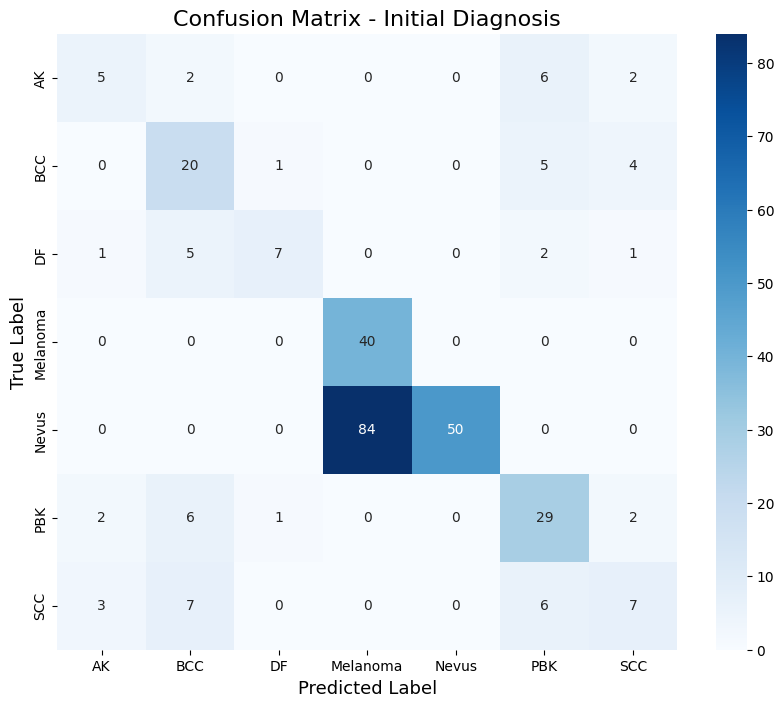


Displaying Confusion Matrix for Final Diagnosis...


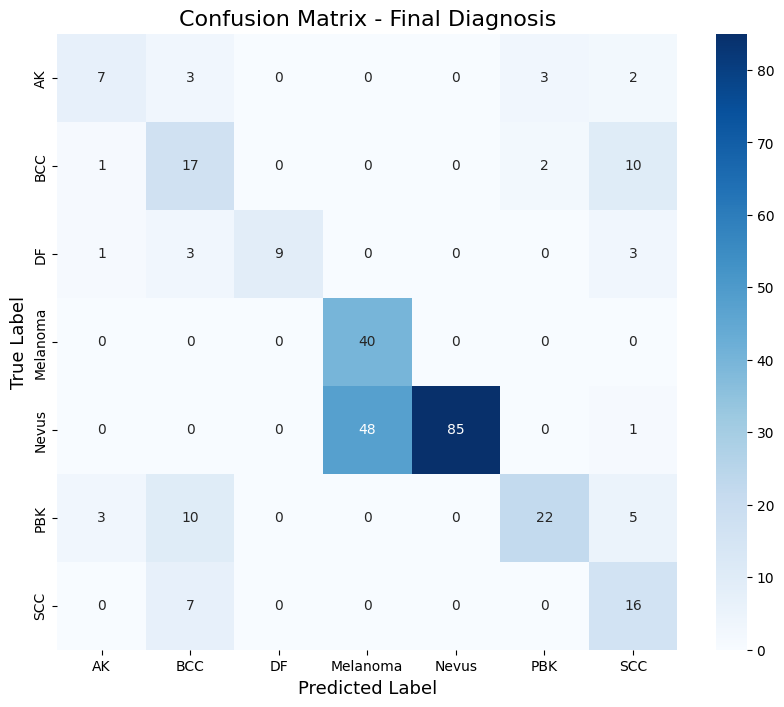

In [31]:
class_labels = ['AK', 'BCC', 'DF', 'Melanoma', 'Nevus', 'PBK', 'SCC']
# 1. Plot the confusion matrix for the INITIAL diagnosis
print("Displaying Confusion Matrix for Initial Diagnosis...")
plot_confusion_matrix(y_true, 
                      y_ini_pred, 
                      class_labels=class_labels, 
                      title='Confusion Matrix - Initial Diagnosis')


# 2. Plot the confusion matrix for the FINAL diagnosis
print("\nDisplaying Confusion Matrix for Final Diagnosis...")
plot_confusion_matrix(y_true, 
                      y_final_pred, 
                      class_labels=class_labels, 
                      title='Confusion Matrix - Final Diagnosis')

In [42]:
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar

# y_true, y_init, y_final are integer arrays of length 300 in [0..6]
K = 7
init_ok  = (y_ini_pred == y_true)
final_ok = (y_final_pred == y_true)

# Overall McNemar
a = int(np.sum(init_ok & final_ok))
b = int(np.sum(init_ok & ~final_ok))
c = int(np.sum(~init_ok & final_ok))
d = int(np.sum(~init_ok & ~final_ok))
res_overall = mcnemar([[a,b],[c,d]], exact=(b+c<25), correction=(b+c>=25))

# Paired OR (+ 0.5 if zero)
b_ = b if b>0 else 0.5
c_ = c if c>0 else 0.5
or_overall = b_/c_

# Per-class McNemar (recall deltas)
per_class = []
pvals = []
for k in range(K):
    idx = (y_true == k)
    if idx.sum() == 0:
        per_class.append({"k": k, "n_true": 0, "p": 1.0})
        pvals.append(1.0)
        continue
    init_hit  = (y_ini_pred[idx]  == k)
    final_hit = (y_final_pred[idx] == k)
    a_k = int(np.sum(init_hit & final_hit))
    b_k = int(np.sum(init_hit & ~final_hit))   # lost a TP
    c_k = int(np.sum(~init_hit & final_hit))   # gained a TP
    d_k = int(np.sum(~init_hit & ~final_hit))
    res_k = mcnemar([[a_k,b_k],[c_k,d_k]], exact=(b_k+c_k<25), correction=(b_k+c_k>=25))
    per_class.append({"k": k, "n_true": int(idx.sum()), "a": a_k, "b": b_k, "c": c_k, "d": d_k,
                      "p": res_k.pvalue})
    pvals.append(res_k.pvalue)

# Holm adjustment
order = np.argsort(pvals)
adj = [None]*K
m = K
running = 0.0
for rank, i in enumerate(order, 1):
    adj_p = pvals[i] * (m - rank + 1)
    running = max(running, adj_p)
    adj[i] = min(1.0, running)
for r in per_class:
    r["p_holm"] = adj[r["k"]]


In [43]:
# After you computed a,b,c,d and res_overall:
print("OVERALL (accuracy improvement)")
print(f"a={a}, b={b}, c={c}, d={d}, n={a+b+c+d}")
print(f"discordant b+c = {b+c}")
print(f"McNemar statistic = {res_overall.statistic:.4f}")
print(f"p-value = {res_overall.pvalue:.6f}")
print(f"paired OR (b/c) = {or_overall:.3f}")
if c > b and res_overall.pvalue < 0.05:
    print("⇒ Significant improvement (final fixes more errors than it introduces).")
elif b > c and res_overall.pvalue < 0.05:
    print("⇒ Significant degradation (final introduces more errors).")
else:
    print("⇒ No significant change.")

OVERALL (accuracy improvement)
a=114, b=44, c=82, d=58, n=298
discordant b+c = 126
McNemar statistic = 10.8651
p-value = 0.000980
paired OR (b/c) = 0.537
⇒ Significant improvement (final fixes more errors than it introduces).
